In [ ]:
import cv2
import numpy as np
import os

# 1. 이미지 로드
img_path = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/1작기/ROI_WARP/step6_warp_images/보정 전/251213-251226/251224/bed03_20251224_063305_cam2.jpg'

# Use np.fromfile and cv2.imdecode for robust handling of paths with non-ASCII characters
n = np.fromfile(img_path, np.uint8)
img = cv2.imdecode(n, cv2.IMREAD_COLOR)

# 이미지 로드 실패 시 에러 처리
if img is None:
    print(f"Error: Could not load image from {img_path}. Check the file path and permissions.")
else:
    # 2. 가우시안 블러 (커널 크기를 홀수로 수정)
    # 1800*600 해상도라면 151~301 사이의 홀수가 적당합니다.
    # 값이 클수록 조명 지도가 더 부드러워집니다.
    k_size =301
    blur = cv2.GaussianBlur(img, (k_size, k_size), 0)

    # 3. 음용 보정 (Shading Correction)
    # 원본을 조명 지도로 나누어 조명 편차를 제거합니다.
    # scale=127은 결과물의 전체적인 밝기 톤을 중간 정도로 맞추는 역할입니다.
    result = cv2.divide(img, blur, scale=127)

    # ensure output directory exists
    output_dir = os.path.dirname('/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images/보ᄌ0ᆼ 전/_logs/bed00_20251224_070413_cam2_after.jpg')
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    cv2.imwrite('/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images/보정 전/_logs/bed00_20251224_070413_cam2_after.jpg', result)

#폴더테스트

In [ ]:
import cv2
import numpy as np
import os

def process_lettuce_shading(img_path, output_path):
    # 1. 이미지 로드
    img = cv2.imread(img_path)
    if img is None: return

    # 2. 조명 지도(Background) 생성
    # 커널 크기를 더 키워(301) 조명 흐름을 더 부드럽게 잡습니다. [cite: 11]
    k_size = 301
    blur = cv2.GaussianBlur(img, (k_size, k_size), 0)

    # 3. 음영 보정 (Shading Correction)
    # scale을 140 정도로 조절하여 너무 어둡지 않게 맞춥니다.
    corrected = cv2.divide(img, blur, scale=140)

    # 4. 블렌딩 (원본 40% : 보정본 60%)
    # 박사님이 느끼신 '부자연스러움'을 해결하는 핵심 단계입니다. [cite: 15]
    # 원본의 자연스러운 대비와 보정본의 균일함을 섞습니다.
    alpha = 0.6  # 보정본 비중
    final_img = cv2.addWeighted(corrected, alpha, img, 1 - alpha, 0)

    # 5. 결과 저장
    cv2.imwrite(output_path, final_img)

# 실행 예시: 폴더 내 모든 이미지 처리
input_dir = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/images'
output_dir = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/images_after1'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for filename in os.listdir(input_dir):
    if filename.endswith(".jpg"):
        process_lettuce_shading(os.path.join(input_dir, filename),
                                os.path.join(output_dir, filename))

#폴더테스트 ver2

In [8]:
import cv2
import numpy as np
import os
import time

# ==========================================
# 1. 경로 설정
# ==========================================
input_dir = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/images'
output_dir = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/images_after_v2'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# ==========================================
# 2. 보정 함수 (LAB 색공간 및 하이라이트 보호 적용)
# ==========================================
def process_lettuce_shading_v2(img_path, output_path):
    # --- 파라미터 조절 (여기서 미세조정 가능) ---
    K_SIZE = 301      # 조명 지도의 부드러움
    SCALE = 128       # 기본 밝기 배율 (140에서 128로 낮춰 번들거림 방지)
    ALPHA = 0.5       # 원본과의 합성 비율 (0.5 = 5:5)
    CLIP_LIMIT = 1.2  # 대비 강조 제한 (낮을수록 하이라이트가 덜 번들거림)
    GAMMA = 1.1       # 1.0보다 크면 밝은 부분을 차분하게 누름
    # ------------------------------------------

    img = cv2.imread(img_path)
    if img is None: return

    # A. 색감 보호를 위해 LAB로 변환 후 L(밝기) 채널만 추출
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # B. 음영 제거 (Shading Correction)
    blur = cv2.GaussianBlur(l, (K_SIZE, K_SIZE), 0)
    l_corrected = cv2.divide(l, blur, scale=SCALE)

    # C. 선명도 및 대비 보정 (번들거림 억제형 CLAHE)
    clahe = cv2.createCLAHE(clipLimit=CLIP_LIMIT, tileGridSize=(8, 8))
    l_final = clahe.apply(l_corrected)

    # D. 블렌딩 (원본의 자연스러움 유지)
    l_blended = cv2.addWeighted(l_final, ALPHA, l, 1 - ALPHA, 0)

    # E. 채널 합치기 및 색공간 복원
    final_lab = cv2.merge((l_blended, a, b))
    result = cv2.cvtColor(final_lab, cv2.COLOR_LAB2BGR)

    # F. 하이라이트를 누르기 위한 감마 보정
    invGamma = 1.0 / GAMMA
    table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    result = cv2.LUT(result, table)

    # 결과 저장
    cv2.imwrite(output_path, result)

# ==========================================
# 3. 실행 및 시간 측정 (Chunks 단위 출력 대신 진행도 표시)
# ==========================================
filenames = [f for f in os.listdir(input_dir) if f.lower().endswith((".jpg", ".png"))]
total_files = len(filenames)

print(f"총 {total_files}개의 파일 처리를 시작합니다.")
start_total = time.time()

for idx, filename in enumerate(filenames):
    in_path = os.path.join(input_dir, filename)
    out_path = os.path.join(output_dir, filename)

    process_lettuce_shading_v2(in_path, out_path)

    # 10장마다 진행 상황 표시
    if (idx + 1) % 10 == 0 or (idx + 1) == total_files:
        print(f"[{idx + 1}/{total_files}] 처리 중... (현재 소요 시간: {time.time() - start_total:.1f}초)")

print(f"최종 완료! 모든 파일이 {output_dir}에 저장되었습니다.")

총 502개의 파일 처리를 시작합니다.
[10/502] 처리 중... (현재 소요 시간: 29.0초)
[20/502] 처리 중... (현재 소요 시간: 37.4초)
[30/502] 처리 중... (현재 소요 시간: 45.3초)
[40/502] 처리 중... (현재 소요 시간: 50.3초)
[50/502] 처리 중... (현재 소요 시간: 56.1초)
[60/502] 처리 중... (현재 소요 시간: 63.4초)
[70/502] 처리 중... (현재 소요 시간: 68.6초)
[80/502] 처리 중... (현재 소요 시간: 75.2초)
[90/502] 처리 중... (현재 소요 시간: 81.1초)
[100/502] 처리 중... (현재 소요 시간: 86.0초)
[110/502] 처리 중... (현재 소요 시간: 93.3초)
[120/502] 처리 중... (현재 소요 시간: 98.5초)
[130/502] 처리 중... (현재 소요 시간: 103.4초)
[140/502] 처리 중... (현재 소요 시간: 111.0초)
[150/502] 처리 중... (현재 소요 시간: 115.8초)
[160/502] 처리 중... (현재 소요 시간: 120.8초)
[170/502] 처리 중... (현재 소요 시간: 128.1초)
[180/502] 처리 중... (현재 소요 시간: 133.0초)
[190/502] 처리 중... (현재 소요 시간: 139.0초)
[200/502] 처리 중... (현재 소요 시간: 145.7초)
[210/502] 처리 중... (현재 소요 시간: 150.9초)
[220/502] 처리 중... (현재 소요 시간: 157.8초)
[230/502] 처리 중... (현재 소요 시간: 163.7초)
[240/502] 처리 중... (현재 소요 시간: 168.5초)
[250/502] 처리 중... (현재 소요 시간: 176.0초)
[260/502] 처리 중... (현재 소요 시간: 181.0초)
[270/502] 처리 중... (현재 소요 시간: 186.0초)


#이미지 테스트

In [ ]:
import cv2
import numpy as np
import os
from google.colab.patches import cv2_imshow # Colab에서 이미지 출력을 위해 추가

def process_lettuce_shading(img_path):
    # 1. 이미지 로드
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not load image from {img_path}")
        return None

    # 2. 조명 지도(Background) 생성
    # 커널 크기를 더 키워(301) 조명 흐름을 더 부드럽게 잡습니다. [cite: 11]
    k_size = 301
    blur = cv2.GaussianBlur(img, (k_size, k_size), 0)

    # 3. 음영 보정 (Shading Correction)
    # scale을 140 정도로 조절하여 너무 어둡지 않게 맞춥니다.
    corrected = cv2.divide(img, blur, scale=140)

    # 4. 블렌딩 (원본 40% : 보정본 60%)
    # 박사님이 느끼신 '부자연스러움'을 해결하는 핵심 단계입니다. [cite: 15]
    # 원본의 자연스러운 대비와 보정본의 균일함을 섞습니다.
    alpha = 0.6  # 보정본 비중
    final_img = cv2.addWeighted(corrected, alpha, img, 1 - alpha, 0)
    gamma = 0.8
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    final_img = cv2.LUT(final_img, table)

    return final_img

# 사용자가 요청한 단일 이미지 경로
input_img_path = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images/보정 전/251213-251226/251224/bed00_20251224_070413_cam2.jpg"

# 이미지 처리 및 결과 출력
processed_image = process_lettuce_shading(input_img_path)

if processed_image is not None:
    print(f"Processed image for: {input_img_path}")
    cv2_imshow(processed_image)
else:
    print(f"Failed to process image: {input_img_path}")

Output hidden; open in https://colab.research.google.com to view.

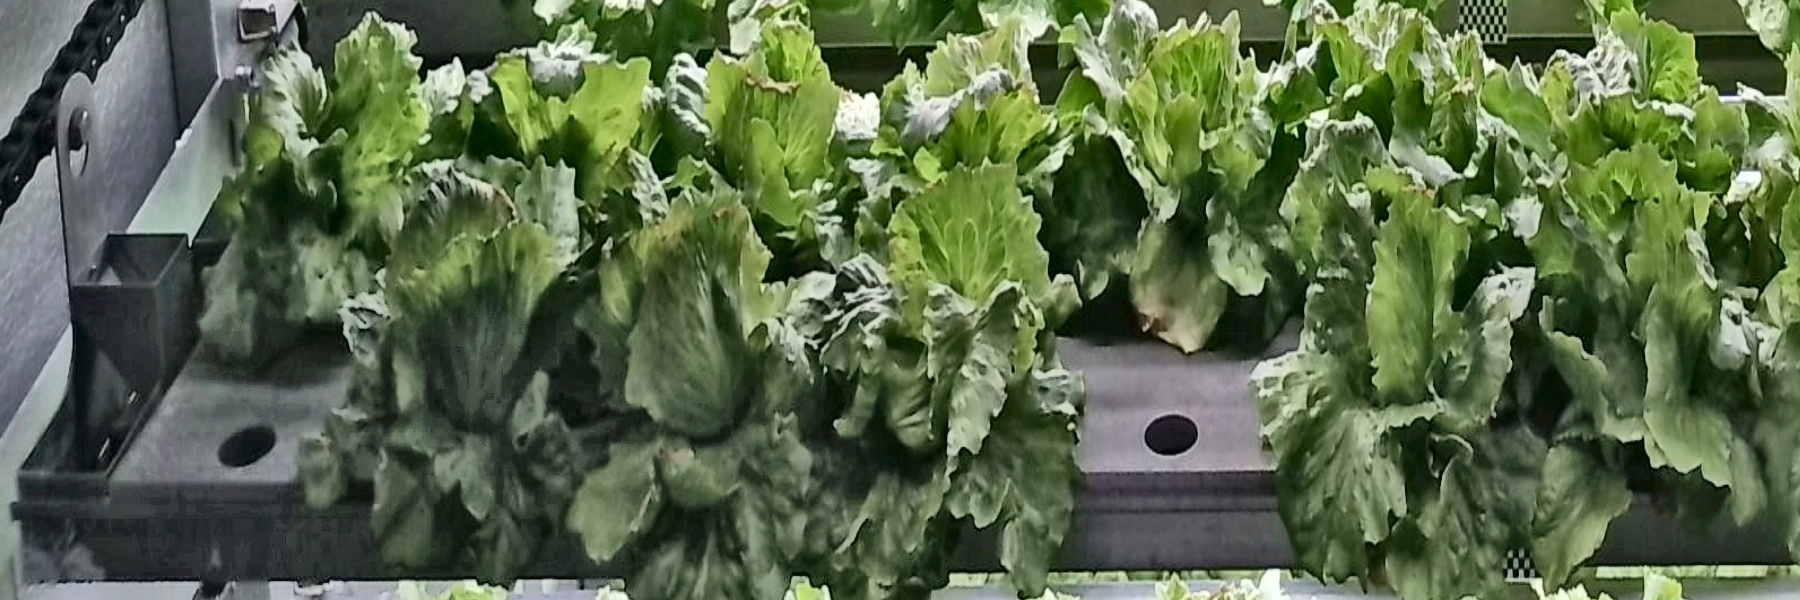

In [7]:
import cv2
import numpy as np
import os
from google.colab.patches import cv2_imshow

def process_lettuce_shading_v2(img_path):
    # 1. 이미지 로드
    img = cv2.imread(img_path)
    if img is None:
        return None

    # --- 수정 포인트 1: LAB 색공간에서 L(밝기)만 건드려 색감 보존 ---
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # --- 수정 포인트 2: 조명 지도 생성 및 음영 제거 ---
    # 가우시안 블러로 배경광 추출 (기존 방식 유지하되 L 채널에만 적용)
    k_size = 301
    blur = cv2.GaussianBlur(l, (k_size, k_size), 0)

    # 음영 보정: scale을 140 -> 128(중간값)로 낮춰 과도한 밝기 방지
    l_corrected = cv2.divide(l, blur, scale=128)

    # --- 수정 포인트 3: CLAHE로 대비 조절 (번들거림 억제) ---
    # clipLimit을 낮게(1.5) 설정하여 하이라이트가 튀는 것을 막음
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    l_final = clahe.apply(l_corrected)

    # --- 수정 포인트 4: 원본과 블렌딩 (자연스러움 유지) ---
    # 보정본의 균일함과 원본의 디테일을 결합
    alpha = 0.5
    l_blended = cv2.addWeighted(l_final, alpha, l, 1 - alpha, 0)

    # LAB 다시 합치기
    final_lab = cv2.merge((l_blended, a, b))
    final_img = cv2.cvtColor(final_lab, cv2.COLOR_LAB2BGR)

    # --- 수정 포인트 5: 감마 보정 방향 수정 ---
    # 기존 0.8(밝게 함) -> 1.2(밝은 곳을 눌러주고 대비를 잡음)로 변경 고려
    # 색감이 이미 충분하다면 감마 단계를 생략하거나 1.0 이상으로 설정
    gamma = 1.1  # 1.0보다 크면 밝은 곳의 들뜸을 눌러줌
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    final_img = cv2.LUT(final_img, table)

    return final_img

# 실행부
input_img_path = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/1작기/ROI_WARP/step6_warp_images/보정 전/251213-251226/251224/bed03_20251224_063305_cam2.jpg"
processed_image = process_lettuce_shading_v2(input_img_path)

if processed_image is not None:
    cv2_imshow(processed_image)